# iniz

In [1]:
import numpy as np
import pandas as pd
import pickle
import glob
import os
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import polyfit

In [2]:
plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["axes.formatter.useoffset"]=False
title_fs = 16
label_fs = 15
tick_fs = 14
legend_fs = 14

In [3]:
def get_scaling_threshold(volumes: np.ndarray, driving_sds: np.ndarray, margin: float = 0.05):
    """Fits sigma = A * V^m and returns a predictor function."""
    log_V = np.log(volumes)
    log_sigma = np.log(driving_sds)
    
    # polyfit returns [intercept, slope]
    coefficients = polyfit(log_V, log_sigma, 1)
    log_A_fit = coefficients[0]
    m_fit = coefficients[1] 
    A_fit = np.exp(log_A_fit)
    
    print(f"Regression Results:")
    print(f" - Fitted Scaling Constant A: {A_fit:.3f}")
    print(f" - Fitted slope m: {m_fit:.3f} (Theoretical expected: -0.5)")
    
    def threshold_function(V_new: float) -> float:
        if V_new <= 0: raise ValueError("Volume must be positive.")
        predicted_sigma = A_fit * (V_new) ** m_fit
        return predicted_sigma * (1 + margin)

    return threshold_function, A_fit, m_fit

# fit with different k values

In [30]:
# --- 1. DATA LOADING AND AGGREGATION ---

# Find all results files generated by the HPC script
pkl_files = glob.glob("results_not_random/resultsv5_V_*.pkl")

data_list = []

for file in pkl_files:
    with open(file, "rb") as f:
        content = pickle.load(f)
        # content is {Volume: [rep1_stds, rep2_stds, ...]}
        for volume, reps_stds in content.items():
            if not reps_stds: continue
            
            # Convert to numpy for easier manipulation: shape (REPS, N_SPECIES)
            reps_stds = np.array(reps_stds)
            
            # Aggregate replicates: Calculate the mean SD for each species at this volume
            mean_stds = np.mean(reps_stds, axis=0)
            
            # Store with volume for sorting later
            data_list.append((volume, mean_stds))

# Sort by volume to ensure plots look correct
data_list.sort(key=lambda x: x[0])
volumes = np.array([x[0] for x in data_list])
all_mean_stds = np.array([x[1] for x in data_list]) # Shape: (Volumes, Species)

In [31]:
# --- 2. IDENTIFY DRIVING SPECIES ---
# Based on the sorting in fun_gilles.py: ['a', 'b', 'c', 'd', 'ab', 'cd', 'acd', 'cab']
# Indices 4, 5, 6, 7 correspond to the complexes/autocatalytic species
driving_species_indices = [4, 5, 6, 7] 
relevant_sds = all_mean_stds[:, driving_species_indices]

# The 'driving' SD is the maximum noise among the autocatalytic species
driving_SD = np.max(relevant_sds, axis=1)

In [32]:
# --- 3. FITTING THE SCALING LAW ---

# Generate predictors
threshold_predictor = get_scaling_threshold(volumes, driving_SD, margin=0.0)[0]
threshold_predictor_w_margin = get_scaling_threshold(volumes, driving_SD, margin=0.5)[0]

Regression Results:
 - Fitted Scaling Constant A: 1.779
 - Fitted slope m: -0.970 (Theoretical expected: -0.5)
Regression Results:
 - Fitted Scaling Constant A: 1.779
 - Fitted slope m: -0.970 (Theoretical expected: -0.5)


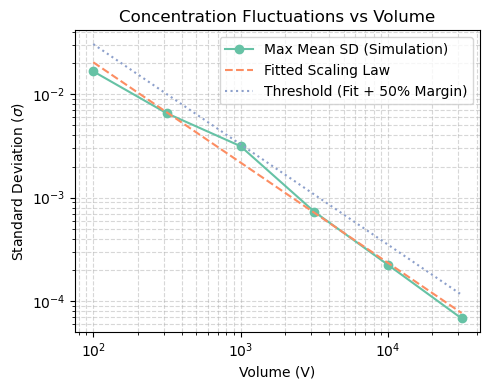

In [33]:
# --- 4. VISUALIZATION ---

plt.figure(figsize=(5,4))
colors = plt.get_cmap('Set2').colors

# Plot actual data
plt.loglog(volumes, driving_SD, 'o-', color=colors[0], label='Max Mean SD (Simulation)')

# Plot fits
v_range = np.logspace(np.log10(volumes.min()), np.log10(volumes.max()), 100)
plt.loglog(v_range, [threshold_predictor(v) for v in v_range], 
           '--', color=colors[1], label='Fitted Scaling Law')
plt.loglog(v_range, [threshold_predictor_w_margin(v) for v in v_range], 
           ':', color=colors[2], label='Threshold (Fit + 50% Margin)')

plt.xlabel('Volume (V)')
plt.ylabel(r'Standard Deviation ($\sigma$)')
plt.title('Concentration Fluctuations vs Volume')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("sd_vs_vol_fit.png")
plt.show()

In [34]:
# --- 5. R-SQUARED CALCULATION ---
y_obs = np.log(driving_SD)
y_pred = np.log([threshold_predictor(v) for v in volumes])
ss_res = np.sum((y_obs - y_pred)**2)
ss_tot = np.sum((y_obs - np.mean(y_obs))**2)
r2_log = 1 - (ss_res / ss_tot)

print(f"Log-Log R-squared: {r2_log:.4f}")

Log-Log R-squared: 0.9913


Now, I want to see if this fit is valid for different k values, so I will loop over the different simulation results.

Results for file :
Regression Results:
 - Fitted Scaling Constant A: 2.719
 - Fitted slope m: -0.884 (Theoretical expected: -0.5)


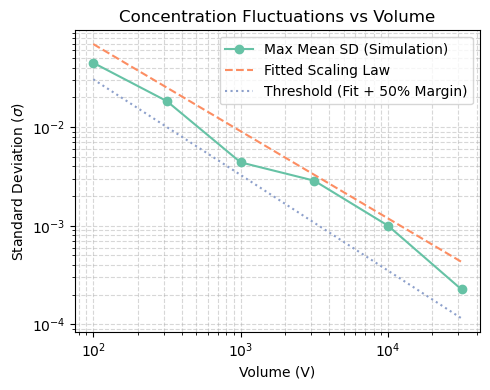

Results for file v2:
Regression Results:
 - Fitted Scaling Constant A: 0.742
 - Fitted slope m: -0.984 (Theoretical expected: -0.5)


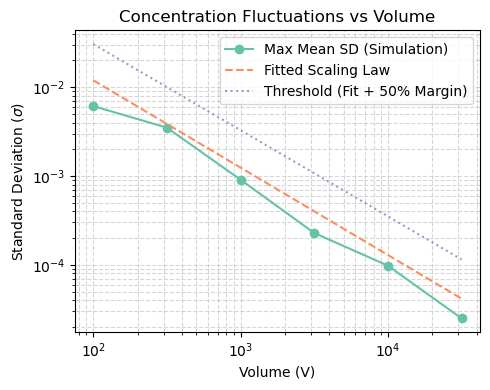

Results for file v3:
Regression Results:
 - Fitted Scaling Constant A: 0.121
 - Fitted slope m: -0.722 (Theoretical expected: -0.5)


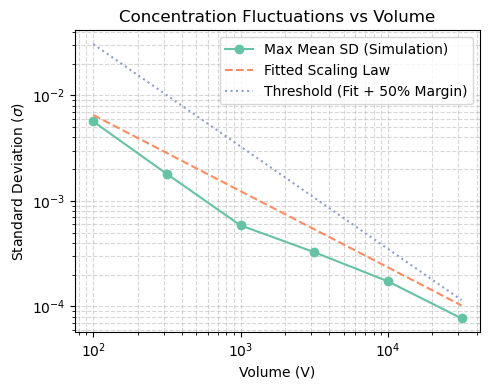

Results for file v4:
Regression Results:
 - Fitted Scaling Constant A: 0.888
 - Fitted slope m: -0.954 (Theoretical expected: -0.5)


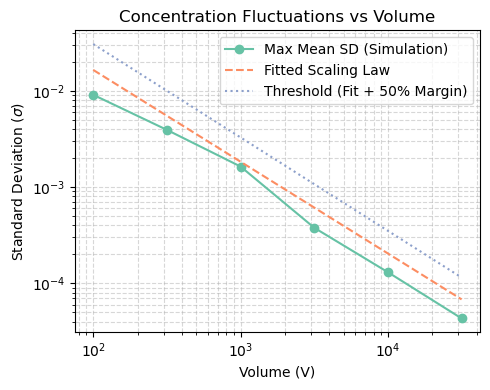

Results for file v5:
Regression Results:
 - Fitted Scaling Constant A: 1.779
 - Fitted slope m: -0.970 (Theoretical expected: -0.5)


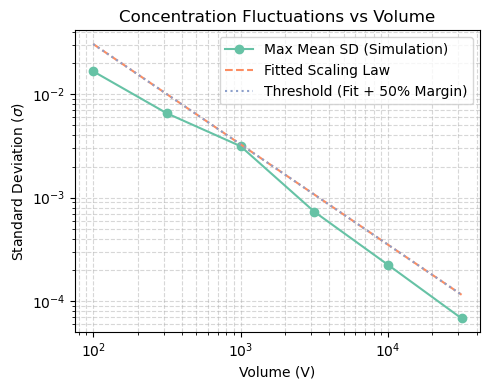

In [35]:
for i in ["", "v2", "v3","v4","v5"]:
    pkl_files = glob.glob(f"results_not_random/results{i}_V_*.pkl")

    data_list = []

    for file in pkl_files:
        with open(file, "rb") as f:
            content = pickle.load(f)
            # content is {Volume: [rep1_stds, rep2_stds, ...]}
            for volume, reps_stds in content.items():
                if not reps_stds: continue
                
                # Convert to numpy for easier manipulation: shape (REPS, N_SPECIES)
                reps_stds = np.array(reps_stds)
                
                # Aggregate replicates: Calculate the mean SD for each species at this volume
                mean_stds = np.mean(reps_stds, axis=0)
                
                # Store with volume for sorting later
                data_list.append((volume, mean_stds))

    # Sort by volume to ensure plots look correct
    data_list.sort(key=lambda x: x[0])
    volumes = np.array([x[0] for x in data_list])
    all_mean_stds = np.array([x[1] for x in data_list]) # Shape: (Volumes, Species)

    driving_species_indices = [4, 5, 6, 7] 
    relevant_sds = all_mean_stds[:,driving_species_indices]

    # The 'driving' SD is the maximum noise among the autocatalytic species
    driving_SD = np.max(relevant_sds, axis=1)
    print(f"Results for file {i}:")
    threshold_predictor = get_scaling_threshold(volumes, driving_SD, margin=0.5)[0]
    # --- 4. VISUALIZATION ---

    plt.figure(figsize=(5,4))
    colors = plt.get_cmap('Set2').colors

    # Plot actual data
    plt.loglog(volumes, driving_SD, 'o-', color=colors[0], label='Max Mean SD (Simulation)')

    # Plot fits
    v_range = np.logspace(np.log10(volumes.min()), np.log10(volumes.max()), 100)
    plt.loglog(v_range, [threshold_predictor(v) for v in v_range], 
            '--', color=colors[1], label='Fitted Scaling Law')
    plt.loglog(v_range, [threshold_predictor_w_margin(v) for v in v_range], 
            ':', color=colors[2], label='Threshold (Fit + 50% Margin)')

    plt.xlabel('Volume (V)')
    plt.ylabel(r'Standard Deviation ($\sigma$)')
    plt.title('Concentration Fluctuations vs Volume')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.savefig("sd_vs_vol_fit.png")
    plt.show()


# run from here !

In [4]:
pkl_files = glob.glob("results_random_k/results_random_V*_K*.pkl")
all_results = []

for file in pkl_files:
    with open(file, "rb") as f:
        all_results.append(pickle.load(f))

# all_results = [{'volume': 100, 'k_idx': 0, 'stds': [[...], [...]]}, ...]

data = []
for entry in all_results:
    v = entry['volume']
    k_id = entry['k_idx']
    # Mean across 5 reps for this specific (V, K)
    mean_std_per_species = np.mean(entry['stds'], axis=0) 
    # Use max SD of the driving species (indices 4:8)
    driving_sd = np.max(mean_std_per_species[4:])
    data.append([v, k_id, driving_sd])

In [5]:
# 1. Extract the Max SD for every (Volume, K_set)
processed_data = []
for entry in all_results:
    # Average across replicates first
    mean_reps = np.mean(entry['stds'], axis=0)
    
    # Identify the max noise among driving species
    driving_sd = np.max(mean_reps[4:8]) 
    
    processed_data.append({
        'Volume': entry['volume'],
        'K_Set': entry['k_idx'],
        'Max_SD': driving_sd
    })

df = pd.DataFrame(processed_data)

# 2. Group by Volume and calculate Mean and SEM
# We use a lambda to calculate SEM directly from the group of K-sets
stats = df.groupby('Volume')['Max_SD'].agg([
    'mean', 
    'std', 
    ('sem', lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))
]).reset_index()

# 3. Extract for plotting
v_fit = stats['Volume'].values
sd_means = stats['mean'].values
sd_errors = stats['std'].values # Use 'sem' here instead of 'std' for cleaner bars

Regression Results:
 - Fitted Scaling Constant A: 0.374
 - Fitted slope m: -0.930 (Theoretical expected: -0.5)


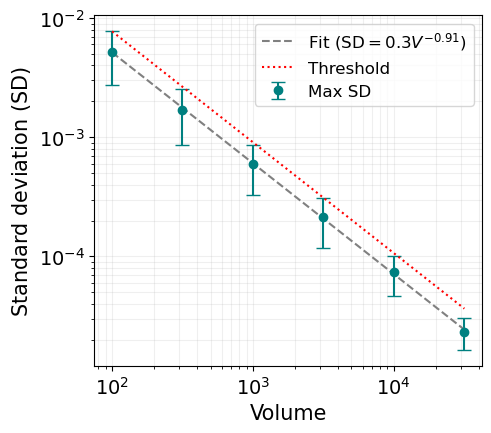

In [14]:

# --- FITTING ---
# Fit the threshold function to the MEANS
threshold_predictor_no_margin = get_scaling_threshold(v_fit, sd_means, margin=0.0)[0]

# --- PLOTTING ---
plt.figure(figsize=(5,4.55))

# Plot the Mean SD with error bars representing the variation across K-sets
plt.errorbar(v_fit, sd_means, yerr=sd_errors, fmt='o', capsize=5, 
             label='Max SD', color='teal')

# Plot the Fitted Function
v_range = np.logspace(np.log10(v_fit.min()), np.log10(v_fit.max()), 100)
plt.loglog(v_range, [threshold_predictor_no_margin(v) for v in v_range], 
           '--', color='gray', label=r'Fit ($\text{SD} = 0.3 V^{-0.91}$)')

# Manually set a margin to "envelop" the data
manual_margin = 0.5 
plt.loglog(v_range, [threshold_predictor_no_margin(v) * (1 + manual_margin) for v in v_range], 
           ':', color='red', label=f'Threshold')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Volume', fontsize=label_fs)
plt.ylabel(r'Standard deviation ($\text{SD}$)', fontsize=label_fs)
plt.legend(fontsize=legend_fs-2, loc='upper right')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tick_params(axis='both', labelsize=tick_fs)
plt.savefig("../figures_TFM/sd_vs_vol_random_k.png", bbox_inches='tight', dpi=300)
# plt.title('Mean noise with random k-sets for different volumes', fontsize=title_fs)
plt.show()

<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
C:\Users\cvzad\AppData\Local\Temp\ipykernel_30300\1073974290.py:22: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('Max Standard Deviation ($\sigma_{max}$)', fontsize=12)


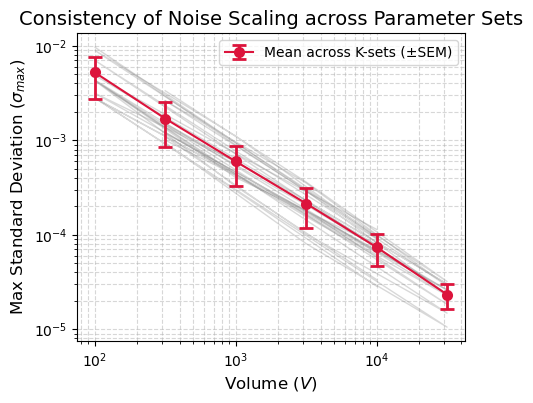

In [7]:
import matplotlib.pyplot as plt

# Assuming 'df' is your long-form dataframe (50 rows: Volume, K_Set, Max_SD)
# And 'stats' is your aggregated dataframe (5 rows: Volume, mean, sem)

plt.figure(figsize=(5,4))

# 1. Plot individual K-sets (The "Spaghetti")
for k_idx in df['K_Set'].unique():
    subset = df[df['K_Set'] == k_idx]
    plt.plot(subset['Volume'], subset['Max_SD'], color='gray', alpha=0.3, lw=1, label='_nolegend_')

# 2. Plot the Mean with SEM Error Bars
plt.errorbar(stats['Volume'], stats['mean'], yerr=stats['std'], 
             fmt='-o', color='crimson', capsize=5, elinewidth=2, markeredgewidth=2,
             label='Mean across K-sets (±SEM)')

# 3. Formatting for Log-Log or Semi-Log
plt.xscale('log')
plt.yscale('log') # Noise scaling usually looks linear on log-log plots
plt.xlabel('Volume ($V$)', fontsize=12)
plt.ylabel('Max Standard Deviation ($\sigma_{max}$)', fontsize=12)
plt.title('Consistency of Noise Scaling across Parameter Sets', fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()

plt.show()

In [8]:
import glob
import pickle
import numpy as np
from scipy.stats import linregress

# 1. Find all result files generated by the HPC array
file_list = glob.glob("results_random_k/results_random_V*_K*.pkl")

volumes = []
sds = []

# 2. Extract and aggregate the data
for f in file_list:
    with open(f, 'rb') as file:
        data = pickle.load(file)
        v = data['volume']
        
        # data['stds'] contains the blocks for the 15 replicates.
        # Each replicate is a list/array of the SDs for all species.
        for rep_stds in data['stds']:
            # Assuming you want to be safe and use the HIGHEST SD among all species 
            # to set your threshold (change to np.mean if you previously averaged them)
            representative_sd = np.max(rep_stds) 
            
            if representative_sd > 0: # Avoid log(0) errors just in case
                volumes.append(v)
                sds.append(representative_sd)

volumes = np.array(volumes)
sds = np.array(sds)

# 3. Log-Log Transformation
# Power law: SD = A * V^m  ==>  log10(SD) = m * log10(V) + log10(A)
log_V = np.log10(volumes)
log_SD = np.log10(sds)

# 4. Perform Linear Regression
res = linregress(log_V, log_SD)

# Extract parameters and their standard errors
m = res.slope
m_err = res.stderr

log_A = res.intercept
log_A_err = res.intercept_stderr

# 5. Convert intercept back to linear scale (A = 10^log_A)
A = 10**log_A

# To get the error of A, we must use error propagation: 
# If f = 10^x, then error_f = f * ln(10) * error_x
A_err = A * np.log(10) * log_A_err

# 6. Print formatted results
print(f"Number of data points: {len(volumes)}")
print("-" * 30)
print(f"Slope (m): {m:.4f} ± {m_err:.4f}")
print(f"Intercept (A): {A:.4f} ± {A_err:.4f}")
print(f"R-squared: {res.rvalue**2:.4f}")
print("-" * 30)
print(f"Final Function: SD = ({A:.1f} ± {A_err:.1f}) * V^({m:.2f} ± {m_err:.2f})")

Number of data points: 900
------------------------------
Slope (m): -0.9116 ± 0.0091
Intercept (A): 0.3059 ± 0.0216
R-squared: 0.9175
------------------------------
Final Function: SD = (0.3 ± 0.0) * V^(-0.91 ± 0.01)
